# Import Libraries and Setup

In [237]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

import pickle
import joblib


In [135]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Load the Data

In [136]:
df = pd.read_excel('./data/CTG.xls', sheet_name='Data', header=1)
df.head()

,b,e,AC,FM,UC,DL,DS,DP,DR,Unnamed: 9,LB,AC.1,FM.1,UC.1,DL.1,DS.1,DP.1,ASTV,MSTV,ALTV,MLTV,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,Unnamed: 31,A,B,C,D,E,AD,DE,LD,FS,SUSP,Unnamed: 42,CLASS,Unnamed: 44,NSP
0,240.0,357.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,120.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,NaN,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,NaN,9.0,NaN,2.0
1,5.0,632.0,4.0,0.0,4.0,2.0,0.0,0.0,0.0,NaN,132.0,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,NaN,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,NaN,6.0,NaN,1.0
2,177.0,779.0,2.0,0.0,5.0,2.0,0.0,0.0,0.0,NaN,133.0,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,NaN,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,NaN,6.0,NaN,1.0
3,411.0,1192.0,2.0,0.0,6.0,2.0,0.0,0.0,0.0,NaN,134.0,0.002561,0.0,0.007682,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,NaN,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,NaN,6.0,NaN,1.0
4,533.0,1147.0,4.0,0.0,5.0,0.0,0.0,0.0,0.0,NaN,132.0,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,NaN,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,NaN,2.0,NaN,1.0


In [137]:
# drop the unnamed columns which are empty
unnamed_columns = [col for col in df.columns if 'Unnamed' in col]
df.drop(columns=unnamed_columns, inplace=True)
df.columns

Index(['b', 'e', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'DR', 'LB', 'AC.1',
       'FM.1', 'UC.1', 'DL.1', 'DS.1', 'DP.1', 'ASTV', 'MSTV', 'ALTV', 'MLTV',
       'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median',
       'Variance', 'Tendency', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS',
       'SUSP', 'CLASS', 'NSP'],
      dtype='str')

In [138]:
df.shape

(2129, 42)

# EDA

In [139]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2129 entries, 0 to 2128
Data columns (total 42 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   b         2126 non-null   float64
 1   e         2126 non-null   float64
 2   AC        2126 non-null   float64
 3   FM        2127 non-null   float64
 4   UC        2127 non-null   float64
 5   DL        2128 non-null   float64
 6   DS        2128 non-null   float64
 7   DP        2128 non-null   float64
 8   DR        2128 non-null   float64
 9   LB        2126 non-null   float64
 10  AC.1      2126 non-null   float64
 11  FM.1      2127 non-null   float64
 12  UC.1      2127 non-null   float64
 13  DL.1      2128 non-null   float64
 14  DS.1      2128 non-null   float64
 15  DP.1      2128 non-null   float64
 16  ASTV      2127 non-null   float64
 17  MSTV      2127 non-null   float64
 18  ALTV      2127 non-null   float64
 19  MLTV      2127 non-null   float64
 20  Width     2126 non-null   float64
 21  Mi

In [140]:
df.describe()

,b,e,AC,FM,UC,DL,DS,DP,DR,LB,AC.1,FM.1,UC.1,DL.1,DS.1,DP.1,ASTV,MSTV,ALTV,MLTV,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,A,B,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
count,2126.000000,2126.000000,2126.000000,2127.000000,2127.000000,2128.000000,2128.000000,2128.000000,2128.0,2126.000000,2126.000000,2127.000000,2127.000000,2128.000000,2128.000000,2128.000000,2127.000000,2127.000000,2127.000000,2127.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2126.000000,2126.000000
mean,878.439793,1702.877234,2.722484,7.503056,3.669017,1.576128,0.003759,0.127820,0.0,133.303857,0.003170,0.009695,0.004362,0.001890,0.000004,0.000159,47.008933,1.335449,9.884814,8.207616,70.445908,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,-0.457922,-0.182887,-0.924777,-0.885284,-0.897978,-0.531265,-0.644100,-0.848613,-0.902210,-0.721674,4.509878,1.304327
std,894.084748,930.919143,3.560850,39.030452,2.877148,2.517794,0.061213,0.471687,0.0,9.840844,0.003860,0.047764,0.002949,0.002976,0.000069,0.000590,17.210648,0.891543,18.476534,5.701926,38.955693,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,8.375478,12.595745,1.210639,1.817135,1.622232,7.250058,5.518616,2.380073,1.557258,4.328211,3.026883,0.614377
min,0.000000,287.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.000000,0.000000,3.000000,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,1.000000
25%,55.000000,1009.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,126.000000,0.000000,0.000000,0.001877,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,2.000000,1.000000
50%,538.000000,1241.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.0,133.000000,0.001630,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.500000,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,4.000000,1.000000
75%,1521.000000,2434.750000,4.000000,2.000000,5.000000,3.000000,0.000000,0.000000,0.0,140.000000,0.005631,0.002527,0.006527,0.003270,0.000000,0.000000,61.000000,1.700000,11.000000,10.800000,100.000000,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,-1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,7.000000,1.000000
max,3296.000000,3599.000000,26.000000,564.000000,23.000000,16.000000,1.000000,4.000000,0.0,160.000000,0.019284,0.480634,0.014925,0.015385,0.001353,0.005348,87.000000,7.000000,91.000000,50.700000,180.000000,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,384.000000,579.000000,53.000000,81.000000,72.000000,332.000000,252.000000,107.000000,69.000000,197.000000,10.000000,3.000000


## Missing Value Handling

In [141]:
df.isnull().sum()

b           3
e           3
AC          3
FM          2
UC          2
DL          1
DS          1
DP          1
DR          1
LB          3
AC.1        3
FM.1        2
UC.1        2
DL.1        1
DS.1        1
DP.1        1
ASTV        2
MSTV        2
ALTV        2
MLTV        2
Width       3
Min         3
Max         3
Nmax        3
Nzeros      3
Mode        3
Mean        3
Median      3
Variance    3
Tendency    3
A           2
B           2
C           2
D           2
E           2
AD          2
DE          2
LD          2
FS          2
SUSP        2
CLASS       3
NSP         3
dtype: int64

In [142]:
# drop rows where any of the features are null
print(df.shape)
df.dropna(how='any', inplace=True)
print(df.shape)

(2129, 42)
(2126, 42)


We see that only three rows of data has been lost. That is not much.

## Encode Categorical Features

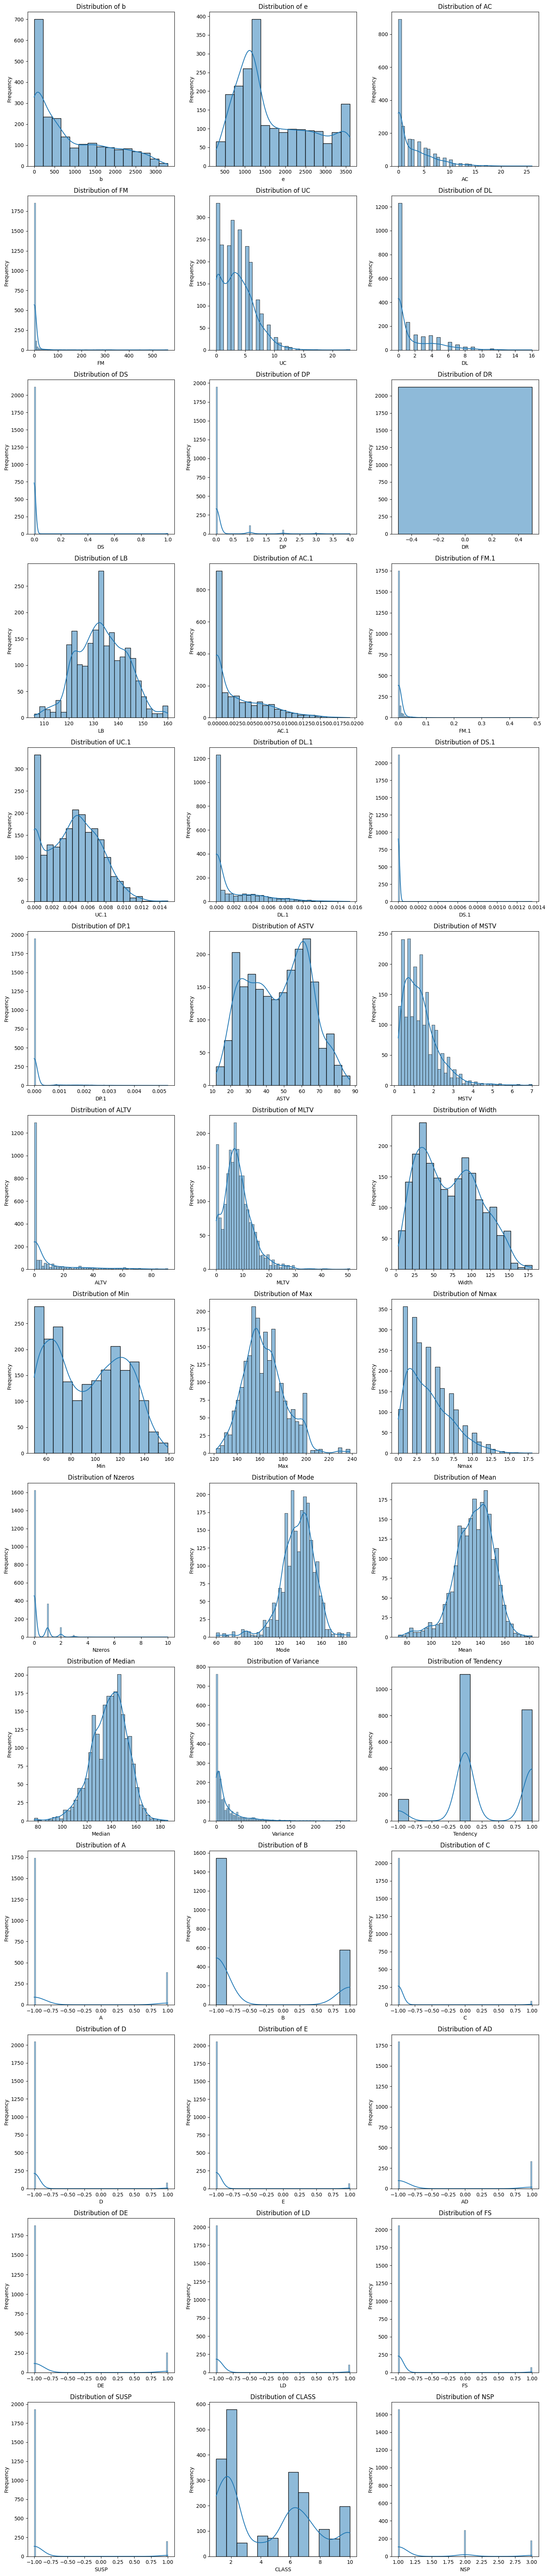

In [143]:
num_features = df.select_dtypes(include=[np.number]).columns
ncols = 3
nrows = len(num_features) // 3
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 5))
axs = axs.flatten()
for i, feature in enumerate(num_features):
    sns.histplot(df[feature], kde=True, ax=axs[i])
    axs[i].set_title(f'Distribution of {feature}')
    axs[i].set_xlabel(feature)
    axs[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

From the distributions, the following features appaer to be categorical:

`cat_features = ['UC', 'DL', 'DP', 'DR', 'Nzeros', 'Tendency', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP', 'CLASS', 'NSP']`

Let's explore them further to confirm

In [144]:
df.columns

Index(['b', 'e', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'DR', 'LB', 'AC.1',
       'FM.1', 'UC.1', 'DL.1', 'DS.1', 'DP.1', 'ASTV', 'MSTV', 'ALTV', 'MLTV',
       'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median',
       'Variance', 'Tendency', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS',
       'SUSP', 'CLASS', 'NSP'],
      dtype='str')

In [145]:
cat_features = ['Tendency', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP', 'CLASS', 'NSP']
for feature in cat_features:
    print(f'Unique values for {feature}: {len(df[feature].unique())} \n')
    print(df[feature].value_counts())
    print()

Unique values for Tendency: 3 

Tendency
 0.0    1115
 1.0     846
-1.0     165
Name: count, dtype: int64

Unique values for A: 2 

A
-1.0    1742
 1.0     384
Name: count, dtype: int64

Unique values for B: 2 

B
-1.0    1547
 1.0     579
Name: count, dtype: int64

Unique values for C: 2 

C
-1.0    2073
 1.0      53
Name: count, dtype: int64

Unique values for D: 2 

D
-1.0    2045
 1.0      81
Name: count, dtype: int64

Unique values for E: 2 

E
-1.0    2054
 1.0      72
Name: count, dtype: int64

Unique values for AD: 2 

AD
-1.0    1794
 1.0     332
Name: count, dtype: int64

Unique values for DE: 2 

DE
-1.0    1874
 1.0     252
Name: count, dtype: int64

Unique values for LD: 2 

LD
-1.0    2019
 1.0     107
Name: count, dtype: int64

Unique values for FS: 2 

FS
-1.0    2057
 1.0      69
Name: count, dtype: int64

Unique values for SUSP: 2 

SUSP
-1.0    1929
 1.0     197
Name: count, dtype: int64

Unique values for CLASS: 10 

CLASS
2.0     579
1.0     384
6.0     332
7.0    

As suspected, these features are categorical or atleast they have discrete and finite values.

In [146]:
num_features = df.columns[~df.columns.isin(cat_features)]
for feature in num_features:
    print(f'Unique values for {feature}: {len(df[feature].unique())} \n')
    #print(df[feature].value_counts())

Unique values for b: 979 

Unique values for e: 1064 

Unique values for AC: 22 

Unique values for FM: 96 

Unique values for UC: 19 

Unique values for DL: 15 

Unique values for DS: 2 

Unique values for DP: 5 

Unique values for DR: 1 

Unique values for LB: 48 

Unique values for AC.1: 1015 

Unique values for FM.1: 696 

Unique values for UC.1: 1315 

Unique values for DL.1: 751 

Unique values for DS.1: 8 

Unique values for DP.1: 166 

Unique values for ASTV: 75 

Unique values for MSTV: 57 

Unique values for ALTV: 87 

Unique values for MLTV: 249 

Unique values for Width: 154 

Unique values for Min: 109 

Unique values for Max: 86 

Unique values for Nmax: 18 

Unique values for Nzeros: 9 

Unique values for Mode: 88 

Unique values for Mean: 103 

Unique values for Median: 95 

Unique values for Variance: 133 



In [147]:
# Check normality of numerical features using D'Agostino-Pearson test
for feature in num_features:
    stat, p = stats.normaltest(df[feature])
    print(f"\n{20*'='} {feature} {20*'='}")
    print(f'Feature: {feature}, Statistic: {stat:.4f}, p-value: {p:.4f}')
    if p < 0.05:
        print(f'{feature} is not normally distributed.')
        if stat > 5.991:
            print(f'{feature} is significantly skewed.')
    else:
        print(f'{feature} is normally distributed.')



==================== b ====================
Feature: b, Statistic: 239.7986, p-value: 0.0000
b is not normally distributed.
b is significantly skewed.

==================== e ====================
Feature: e, Statistic: 326.3402, p-value: 0.0000
e is not normally distributed.
e is significantly skewed.

==================== AC ====================
Feature: AC, Statistic: 667.4274, p-value: 0.0000
AC is not normally distributed.
AC is significantly skewed.

==================== FM ====================
Feature: FM, Statistic: 3228.1383, p-value: 0.0000
FM is not normally distributed.
FM is significantly skewed.

==================== UC ====================
Feature: UC, Statistic: 251.5181, p-value: 0.0000
UC is not normally distributed.
UC is significantly skewed.

==================== DL ====================
Feature: DL, Statistic: 728.5004, p-value: 0.0000
DL is not normally distributed.
DL is significantly skewed.

==================== DS ====================
Feature: DS, Statistic: 4

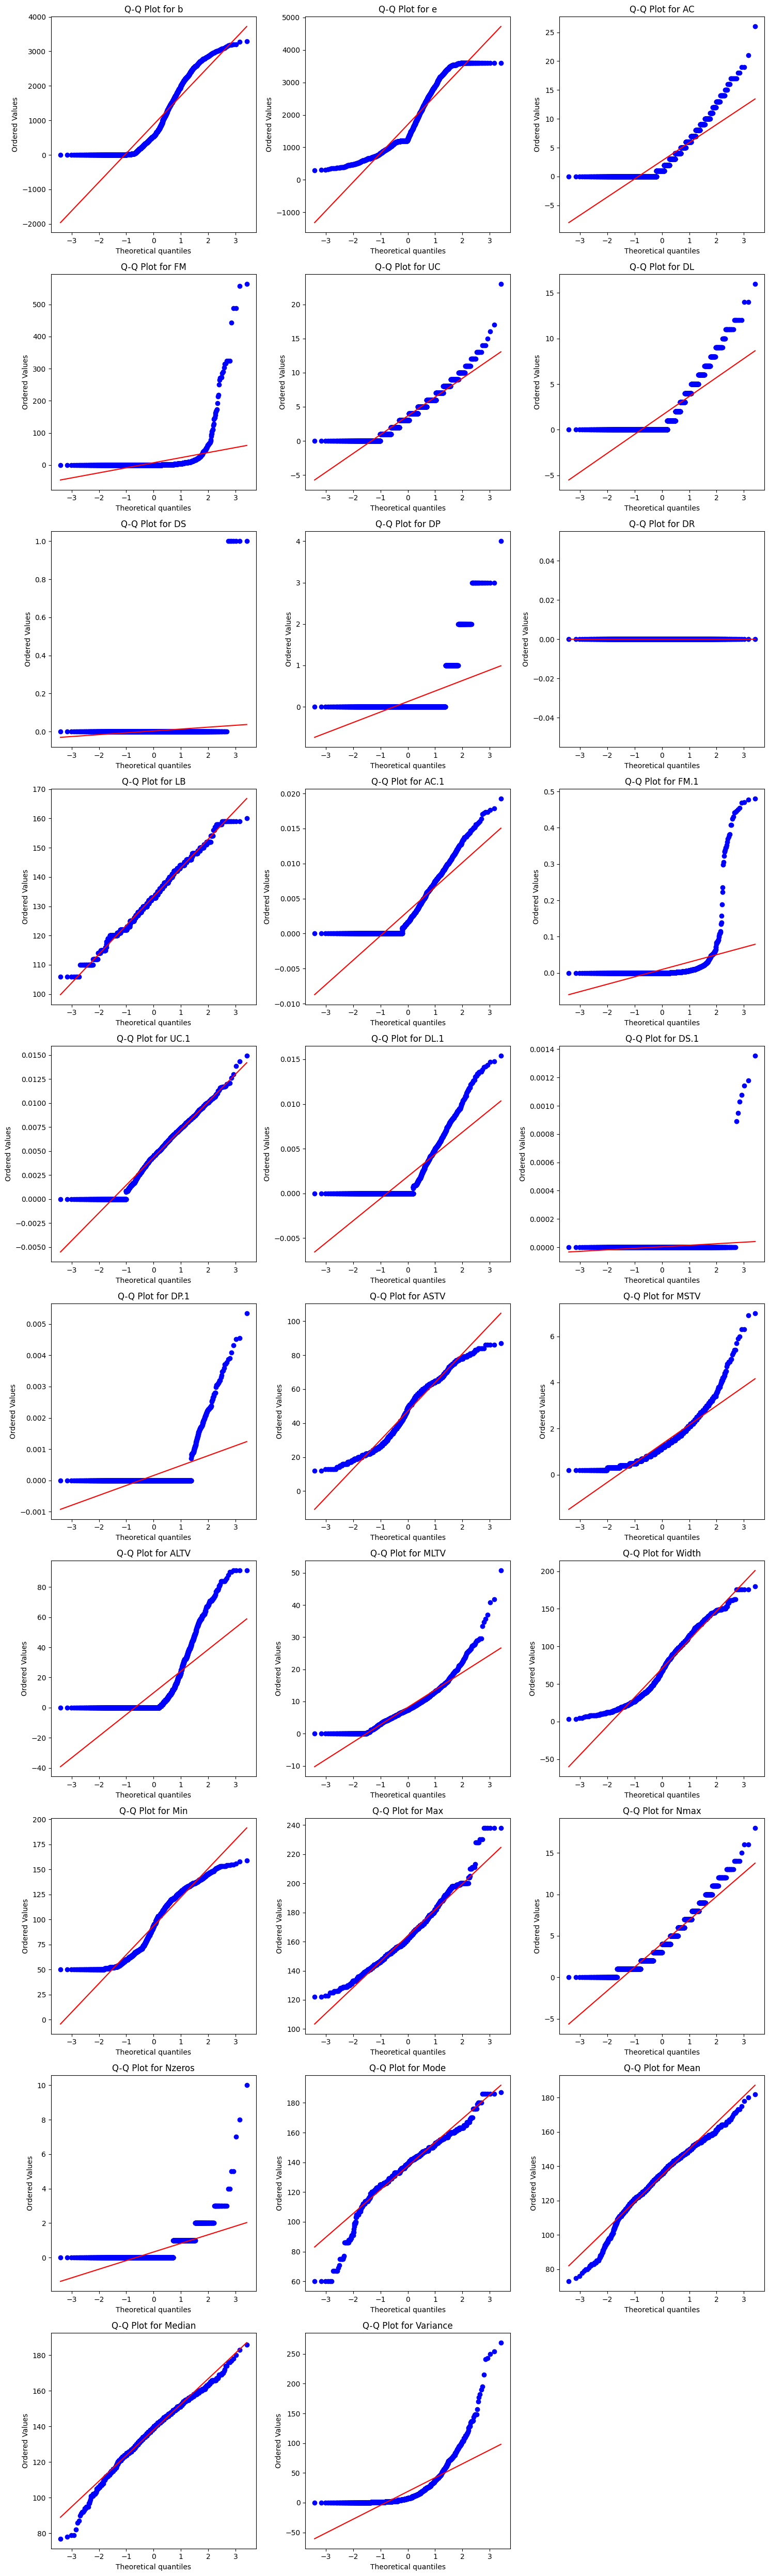

In [148]:
# Checking for normality of numerical features using Q-Q plots
import scipy.stats as stats
ncols = 3
nrows = len(num_features) // 3 + (len(num_features) % 3 > 0)
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 5))
axs = axs.flatten()
for i, feature in enumerate(num_features):
    stats.probplot(df[feature], dist="norm", plot=axs[i])
    axs[i].set_title(f'Q-Q Plot for {feature}')

# 2. Remove any remaining empty subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

None of the numerical features are normally distributed. Let's look at outliers.

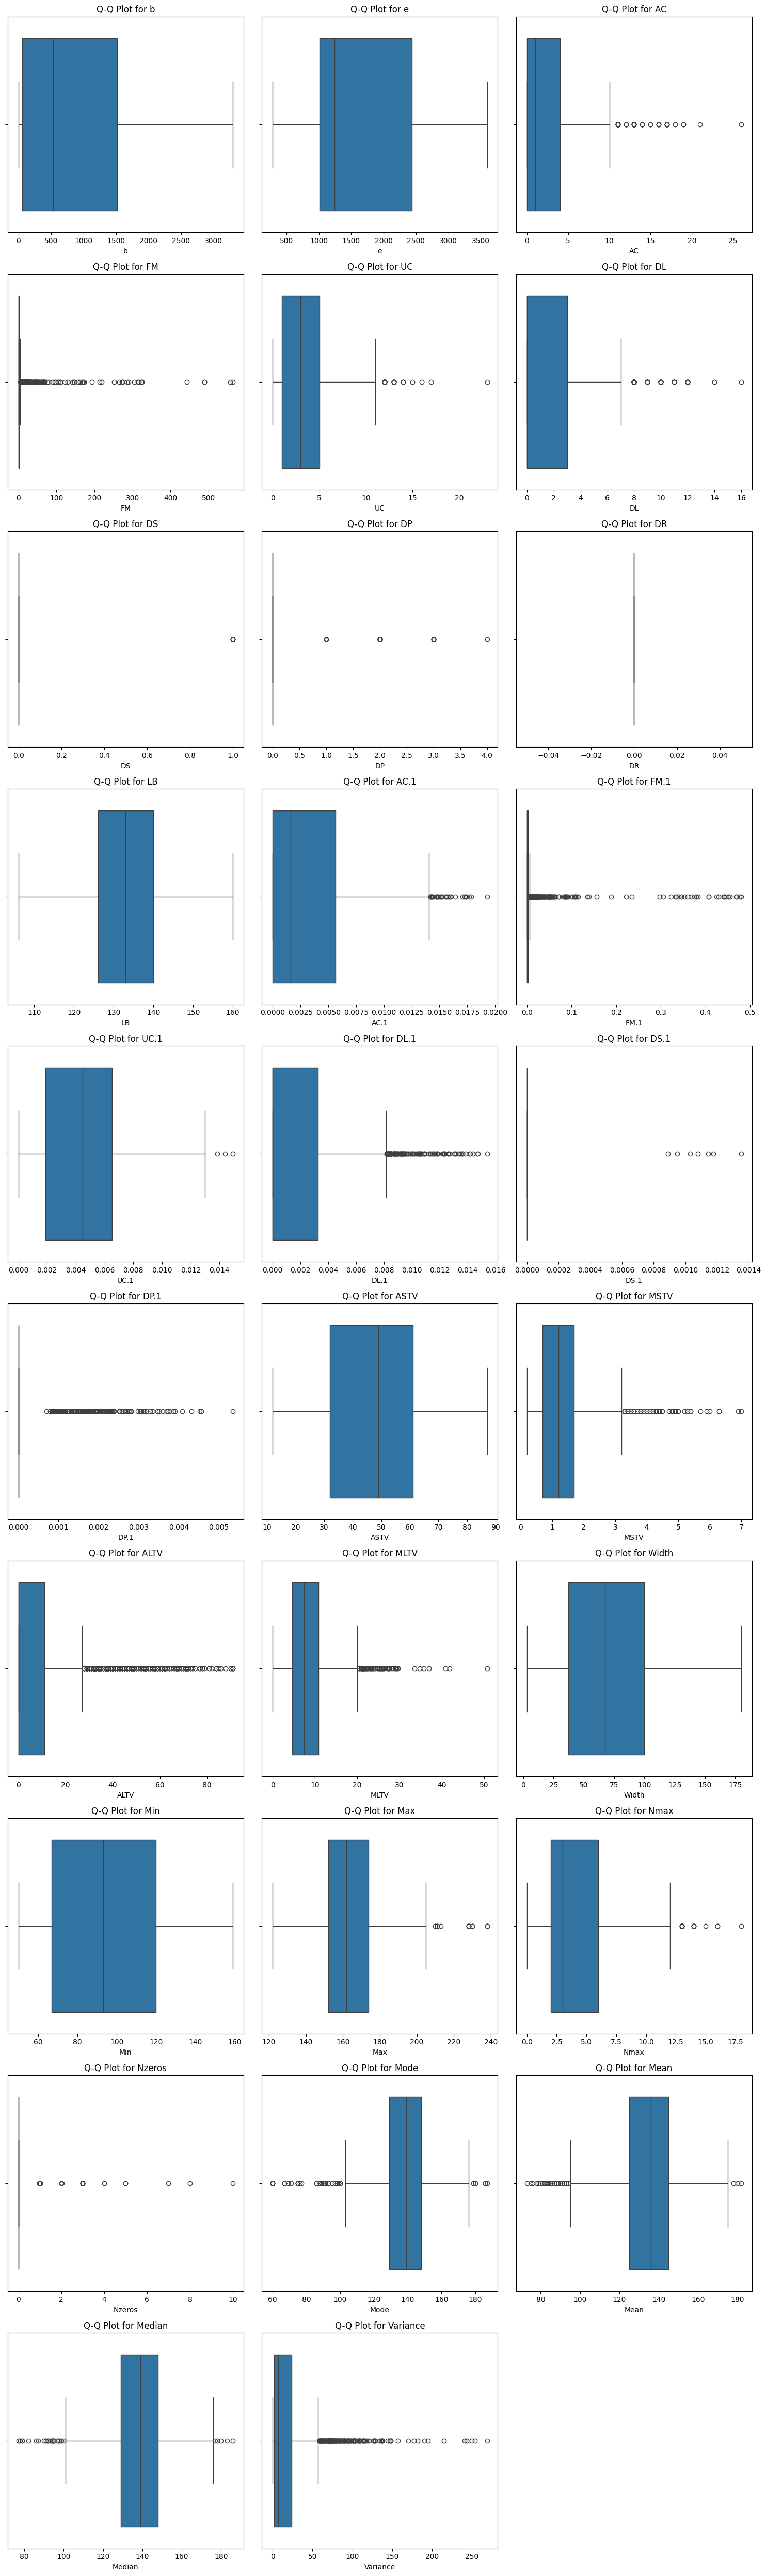

In [149]:
ncols = 3
nrows = len(num_features) // 3 + (len(num_features) % 3 > 0)
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 5))
axs = axs.flatten()
for i, feature in enumerate(num_features):
    sns.boxplot(x=df[feature], ax=axs[i])
    axs[i].set_title(f'Q-Q Plot for {feature}')

# 2. Remove any remaining empty subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

The outliers may be due to actual abnormality. Let's investigate the nature of outliers

In [150]:
def find_outliers_iqr(data, feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)][[feature, 'NSP']]
    # outlier_indices = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)].index
    return outliers


In [151]:
for feature in num_features:
    print(f'\nOutliers for {feature}:')
    ols = find_outliers_iqr(df, feature)
    print(ols['NSP'].value_counts())


Outliers for b:
Series([], Name: count, dtype: int64)

Outliers for e:
Series([], Name: count, dtype: int64)

Outliers for AC:
NSP
1.0    83
Name: count, dtype: int64

Outliers for FM:
NSP
1.0    225
2.0     58
3.0     27
Name: count, dtype: int64

Outliers for UC:
NSP
1.0    15
3.0     6
2.0     1
Name: count, dtype: int64

Outliers for DL:
NSP
1.0    51
3.0    29
2.0     1
Name: count, dtype: int64

Outliers for DS:
NSP
3.0    6
1.0    1
Name: count, dtype: int64

Outliers for DP:
NSP
3.0    94
1.0    69
2.0    15
Name: count, dtype: int64

Outliers for DR:
Series([], Name: count, dtype: int64)

Outliers for LB:
Series([], Name: count, dtype: int64)

Outliers for AC.1:
NSP
1.0    30
Name: count, dtype: int64

Outliers for FM.1:
NSP
1.0    242
2.0     65
3.0     30
Name: count, dtype: int64

Outliers for UC.1:
NSP
1.0    2
3.0    1
Name: count, dtype: int64

Outliers for DL.1:
NSP
1.0    80
3.0    35
2.0     3
Name: count, dtype: int64

Outliers for DS.1:
NSP
3.0    6
1.0    1
Name: 

Since, there are outliers in every fetal state, therefore, I can't say with certainity if the outliers are due to abnormal data acquisition, or actual system state. Let's retain the outliers for now.

### Check for Multicollinearity

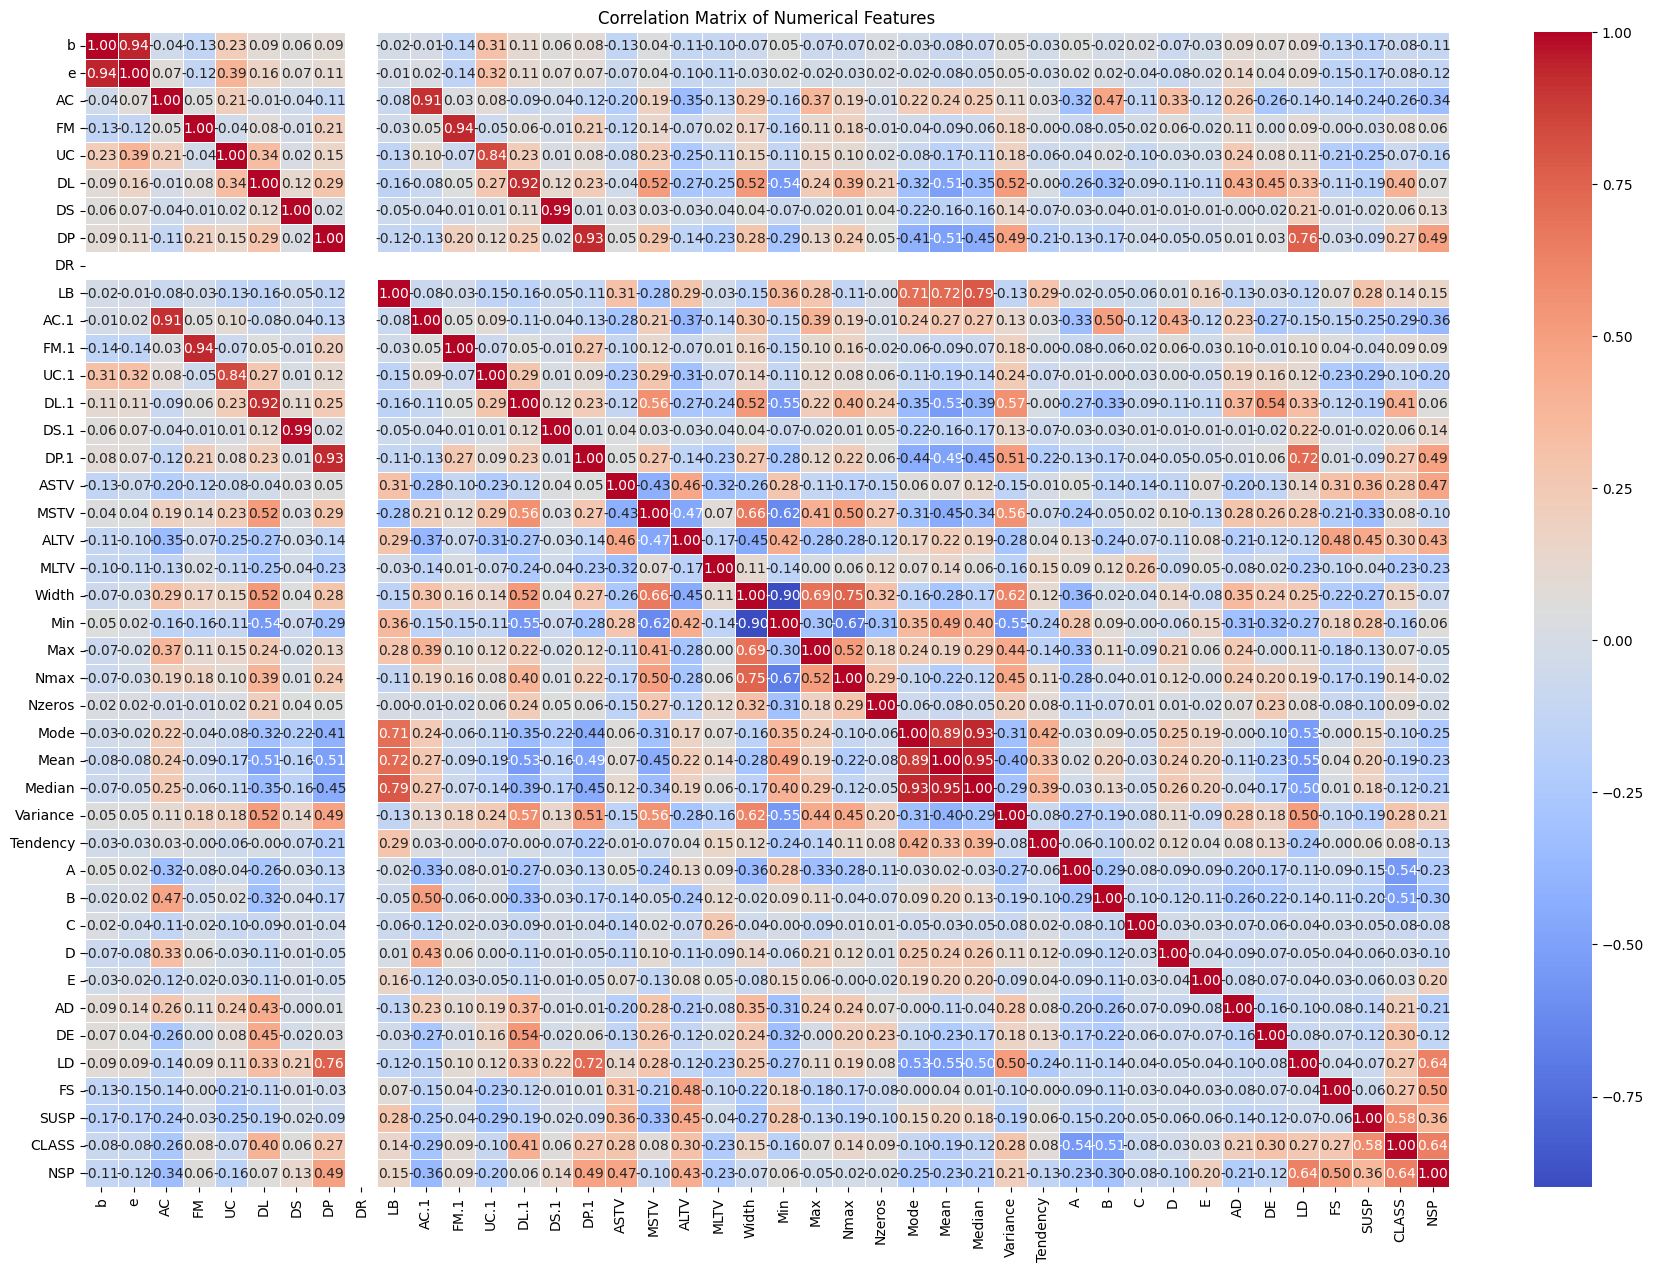

In [152]:
corr_mat = df.corr()
plt.figure(figsize=(22, 15))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [153]:
for i in df.columns:
    for j in df.columns:
        if i != j:
            corr, p_value = stats.pearsonr(df[i], df[j])
            if corr > 0.8 or corr < -0.8:
                print("\nHigh correlation detected:")
                print(f'Correlation between {i} and {j}: {corr:.4f}, p-value: {p_value:.4f}')


High correlation detected:
Correlation between b and e: 0.9449, p-value: 0.0000

High correlation detected:
Correlation between e and b: 0.9449, p-value: 0.0000

High correlation detected:
Correlation between AC and AC.1: 0.9145, p-value: 0.0000

High correlation detected:
Correlation between FM and FM.1: 0.9362, p-value: 0.0000

High correlation detected:
Correlation between UC and UC.1: 0.8375, p-value: 0.0000


C:\Users\Admin\AppData\Local\Temp\ipykernel_11876\1154292199.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = stats.pearsonr(df[i], df[j])



High correlation detected:
Correlation between DL and DL.1: 0.9222, p-value: 0.0000

High correlation detected:
Correlation between DS and DS.1: 0.9914, p-value: 0.0000

High correlation detected:
Correlation between DP and DP.1: 0.9283, p-value: 0.0000

High correlation detected:
Correlation between AC.1 and AC: 0.9145, p-value: 0.0000

High correlation detected:
Correlation between FM.1 and FM: 0.9362, p-value: 0.0000

High correlation detected:
Correlation between UC.1 and UC: 0.8375, p-value: 0.0000

High correlation detected:
Correlation between DL.1 and DL: 0.9222, p-value: 0.0000

High correlation detected:
Correlation between DS.1 and DS: 0.9914, p-value: 0.0000

High correlation detected:
Correlation between DP.1 and DP: 0.9283, p-value: 0.0000

High correlation detected:
Correlation between Width and Min: -0.8985, p-value: 0.0000

High correlation detected:
Correlation between Min and Width: -0.8985, p-value: 0.0000

High correlation detected:
Correlation between Mode and Me

The following strong correlations are observed:
|Feature 1 | Feature 2 | Correlation Value | Remarks |
|----------| --------- | ------------------| ------- |
| UC | UC.1 | 0.84 | This is expected since Uterine Contractions is a multiple of Uterine Contractions per second. |
| DL | DL.1 | 0.92 | This is expected since Late Decelerations is a multiple of Late Decelerations per second |
| DS | DS.1 | 0.99 | This is expected since Short Decelerations is a muliple of Short Decelerations per second |
| DP | DP.1 | 0.93 | This is expected since Prolonged Decelerations is a multiple of Prolonged Decelerations per second |
| AC | AC.1 | 0.91 | This is expected since, Acceleration is a multiple of Acceleration per second. |
| FM | FM.1 | 0.94 | This the expected since, Fetal Movement is a multiple of Fetal Movement per second. |
| b | e | 0.94 | These are start and end time of GCT, therefore, not significant for prediction. May be dropped. |
| Min | Width | -0.9 | Width = Max - Min, Min and Max can be dropped. |
| Max | Width | 0.69 | Width = Max - Min, Min and Max can be dropped. |

In addition to these, there is a high correlation between `Mean`, `Median`, and `Mode`. However, I shall not drop them from further analysis because they represent a skew in the data.
Further, `DR` has only a single value *0.0* for the entire dataset. Therefore, it does not add much value towards further anlaysis. It is also dropped.

Based on these observations, the following features may be dropped:
`features_to_drop = ['AC.1', 'FM.1', 'b', 'e', 'Min', 'Max', 'UC.1', 'DL.1', 'DS.1', 'DP.1', 'DR']`

In [154]:
features_to_drop = ['AC.1', 'FM.1', 'b', 'e', 'Min', 'Max', 'UC.1', 'DL.1', 'DS.1', 'DP.1', 'DR']

In [155]:
print(df.shape)
df = df.drop(columns=features_to_drop)
print(df.shape)

(2126, 42)
(2126, 31)


### Scaling
Sincer there are outliers in the data, that we cant remove, therefore, RobustScaler is the best choice for scaling numerical features. This Scaler removes the median and scales the data according to the quantile range (defaults to IQR: Interquartile Range). The IQR is the range between the 1st quartile (25th quantile) and the 3rd quartile (75th quantile).

In [160]:
final_num_features = [f for f in num_features if f not in features_to_drop]
final_cat_features = [f for f in cat_features if f not in features_to_drop]
final_cat_features.remove('NSP')
target_feature = 'NSP'

In [161]:
final_num_features, final_cat_features, target_feature

(['AC',
  'FM',
  'UC',
  'DL',
  'DS',
  'DP',
  'LB',
  'ASTV',
  'MSTV',
  'ALTV',
  'MLTV',
  'Width',
  'Nmax',
  'Nzeros',
  'Mode',
  'Mean',
  'Median',
  'Variance'],
 ['Tendency',
  'A',
  'B',
  'C',
  'D',
  'E',
  'AD',
  'DE',
  'LD',
  'FS',
  'SUSP',
  'CLASS'],
 'NSP')

In [163]:
scaled_df = df.copy()
scaled_df[final_num_features] = RobustScaler().fit_transform(df[final_num_features])

In [164]:
scaled_df.sample(5)

,AC,FM,UC,DL,DS,DP,LB,ASTV,MSTV,ALTV,MLTV,Width,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,A,B,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
942,0.50,0.0,0.25,0.000000,0.0,0.0,0.214286,0.172414,-0.5,1.363636,0.500000,-0.388889,1.00,0.0,-0.157895,0.25,0.105263,0.045455,0.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,2.0,1.0
1594,-0.25,0.0,-0.25,1.000000,0.0,0.0,0.071429,-0.965517,0.7,0.000000,0.193548,0.579365,1.50,2.0,-0.684211,-0.95,-0.631579,2.590909,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,7.0,1.0
1607,1.25,22.0,0.00,0.333333,0.0,0.0,0.000000,0.517241,0.8,0.000000,-0.467742,-0.055556,0.00,0.0,0.157895,-0.30,0.157895,-0.181818,1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,2.0,1.0
1151,1.25,0.0,-0.75,0.000000,0.0,0.0,-0.785714,-0.827586,0.3,0.000000,0.564516,0.071429,0.75,2.0,-0.157895,-0.35,-0.315789,0.318182,1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,2.0,1.0
235,0.75,3.5,-0.75,0.000000,0.0,0.0,-0.857143,0.241379,-0.6,0.181818,0.500000,0.150794,0.00,0.0,-0.631579,-0.40,-0.526316,-0.181818,1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,2.0,1.0


### Dummy Encoding for Categorical Features

In [166]:
scaled_encoded_df = scaled_df.copy()
scaled_encoded_df = pd.get_dummies(scaled_encoded_df, columns=final_cat_features, drop_first=True, dtype=np.uint8)
scaled_encoded_df.sample(5)

,AC,FM,UC,DL,DS,DP,LB,ASTV,MSTV,ALTV,MLTV,Width,Nmax,Nzeros,Mode,Mean,Median,Variance,NSP,Tendency_0.0,Tendency_1.0,A_1.0,B_1.0,C_1.0,D_1.0,E_1.0,AD_1.0,DE_1.0,LD_1.0,FS_1.0,SUSP_1.0,CLASS_2.0,CLASS_3.0,CLASS_4.0,CLASS_5.0,CLASS_6.0,CLASS_7.0,CLASS_8.0,CLASS_9.0,CLASS_10.0
1743,3.00,1.0,1.50,2.333333,0.0,0.0,0.071429,0.344828,0.0,0.000000,-1.096774,0.500000,0.50,0.0,0.631579,0.45,0.631579,1.590909,1.0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
551,2.75,0.0,1.00,0.000000,0.0,0.0,0.214286,-0.482759,4.5,0.000000,3.580645,1.277778,0.50,3.0,0.368421,0.70,0.631579,2.500000,1.0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
747,0.00,0.0,0.50,2.666667,0.0,0.0,0.642857,-0.827586,1.9,0.000000,-0.790323,1.214286,1.00,0.0,0.210526,-0.35,-0.105263,2.227273,1.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
1566,0.00,0.0,-0.25,0.000000,0.0,0.0,0.857143,-0.034483,-0.5,0.181818,-0.177419,-0.468254,-0.25,0.0,1.105263,1.15,1.105263,-0.227273,1.0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1595,-0.25,0.0,-0.25,1.000000,0.0,0.0,0.071429,-0.931034,0.9,0.000000,0.096774,0.690476,0.50,2.0,-0.684211,-0.90,-0.631579,2.363636,1.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0


### Train Test Split

In [168]:
X = scaled_encoded_df.drop(columns=target_feature)
y = scaled_encoded_df[target_feature]

X.shape, y.shape

((2126, 39), (2126,))

In [169]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1700, 39), (426, 39), (1700,), (426,))

# Train Base Models

The following classification algorithms are selected:
- LogisticRegression
- RandomForestClassifier, 
- GradientBoostingClassifier
- SVC
- KNeighborsClassifier

These models will be trained with default parameters

In [192]:
def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, label=None, save_report=True):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    classification_report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()
    print(classification_report_df)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix for {model.__class__.__name__}')
    plt.show()
    # Save the classification report to a JSON file
    if save_report:
        report_path = f'./reports/{model.__class__.__name__}_{label}_report.json'
        with open(report_path, 'w') as f:
            json.dump({f'{model.__class__.__name__}_{label}': classification_report_df.to_dict()}, f, indent=4)

    return classification_report_df

## Logistic Regression

              precision    recall  f1-score     support
1.0            0.982249  1.000000  0.991045  332.000000
2.0            1.000000  0.898305  0.946429   59.000000
3.0            1.000000  1.000000  1.000000   35.000000
accuracy       0.985915  0.985915  0.985915    0.985915
macro avg      0.994083  0.966102  0.979158  426.000000
weighted avg   0.986166  0.985915  0.985601  426.000000


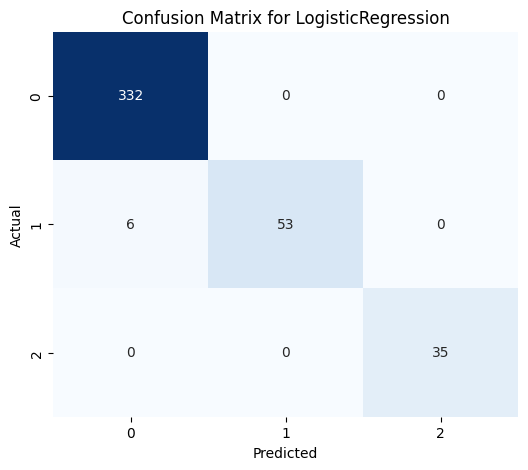

In [ ]:
lr_base = LogisticRegression(random_state=42, max_iter=1000)
lr_base_report = train_and_evaluate_model(lr_base, X_train, y_train, X_test, y_test, label='Base')

## Random Forest Classifier

              precision    recall  f1-score     support
1.0            0.976471  1.000000  0.988095  332.000000
2.0            1.000000  0.864407  0.927273   59.000000
3.0            1.000000  1.000000  1.000000   35.000000
accuracy       0.981221  0.981221  0.981221    0.981221
macro avg      0.992157  0.954802  0.971789  426.000000
weighted avg   0.981663  0.981221  0.980650  426.000000


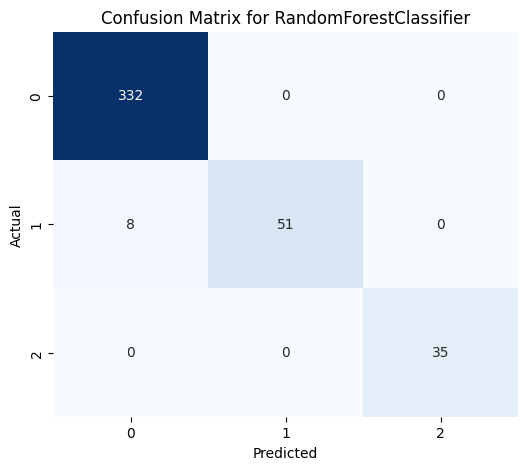

In [194]:
rf_base = RandomForestClassifier(random_state=42)
rf_base_report = train_and_evaluate_model(rf_base, X_train, y_train, X_test, y_test, label='Base')

## Gradient Boosting Classifier

              precision    recall  f1-score     support
1.0            0.979290  0.996988  0.988060  332.000000
2.0            0.981132  0.881356  0.928571   59.000000
3.0            1.000000  1.000000  1.000000   35.000000
accuracy       0.981221  0.981221  0.981221    0.981221
macro avg      0.986807  0.959448  0.972210  426.000000
weighted avg   0.981247  0.981221  0.980802  426.000000


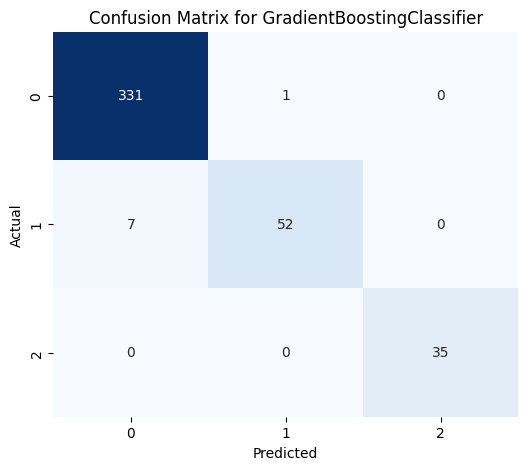

In [195]:
gb_base = GradientBoostingClassifier(random_state=42)
gb_base_report = train_and_evaluate_model(gb_base, X_train, y_train, X_test, y_test, label='Base')

## Support Vector Classifier

              precision    recall  f1-score     support
1.0            0.940510  1.000000  0.969343  332.000000
2.0            0.909091  0.677966  0.776699   59.000000
3.0            0.965517  0.800000  0.875000   35.000000
accuracy       0.938967  0.938967  0.938967    0.938967
macro avg      0.938373  0.825989  0.873681  426.000000
weighted avg   0.938213  0.938967  0.934911  426.000000


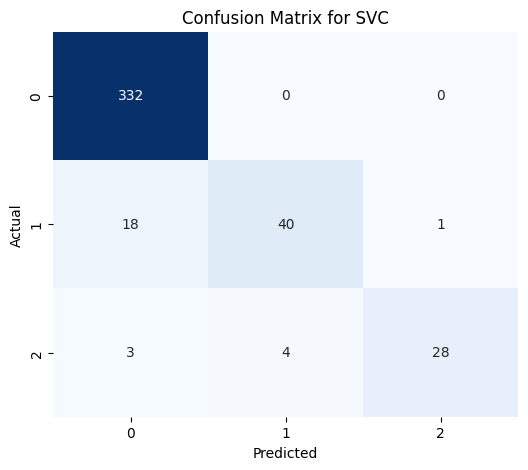

In [196]:
svc_base = SVC(random_state=42)
svc_base_report = train_and_evaluate_model(svc_base, X_train, y_train, X_test, y_test, label='Base')

## K Nearest Neighbors

              precision    recall  f1-score     support
1.0            0.973529  0.996988  0.985119  332.000000
2.0            1.000000  0.881356  0.936937   59.000000
3.0            0.970588  0.942857  0.956522   35.000000
accuracy       0.976526  0.976526  0.976526    0.976526
macro avg      0.981373  0.940400  0.959526  426.000000
weighted avg   0.976954  0.976526  0.976096  426.000000


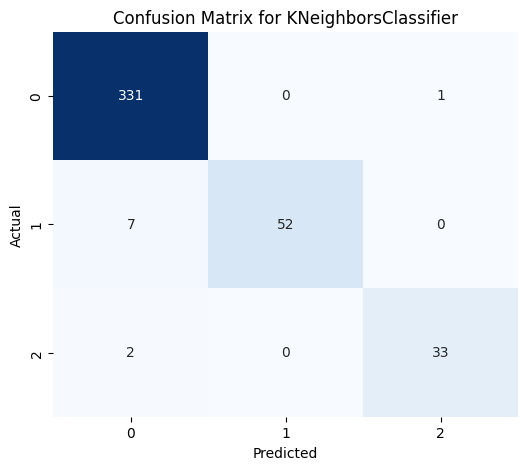

In [197]:
knn_base = KNeighborsClassifier()
knn_base_report = train_and_evaluate_model(knn_base, X_train, y_train, X_test, y_test, label='Base')

### combined classification report for comparison

In [201]:
combined_base_report = pd.concat(
    objs=[lr_base_report, rf_base_report, gb_base_report, svc_base_report, knn_base_report], 
    keys=['Logistic Regression', 'Random Forest', 'Gradient Boosted Classifier', 'SVC', 'KNN']
)

combined_base_report

precision    recall  f1-score  \
Logistic Regression         1.0            0.982249  1.000000  0.991045   
                            2.0            1.000000  0.898305  0.946429   
                            3.0            1.000000  1.000000  1.000000   
                            accuracy       0.985915  0.985915  0.985915   
                            macro avg      0.994083  0.966102  0.979158   
                            weighted avg   0.986166  0.985915  0.985601   
Random Forest               1.0            0.976471  1.000000  0.988095   
                            2.0            1.000000  0.864407  0.927273   
                            3.0            1.000000  1.000000  1.000000   
                            accuracy       0.981221  0.981221  0.981221   
                            macro avg      0.992157  0.954802  0.971789   
                            weighted avg   0.981663  0.981221  0.980650   
Gradient Boosted Classifier 1.0            0.979290  0.996988  0.988060   
                            2.0            0.981132  0.881356  0.928571   
                            3.0            1.000000  1.000000  1.000000   
                            accuracy       0.981221  0.981221  0.981221   
                            macro avg      0.986807  0.959448  0.972210   
                            weighted avg   0.981247  0.981221  0.980802   
SVC                         1.0            0.940510  1.000000  0.969343   
                            2.0            0.909091  0.677966  0.776699   
                            3.0            0.965517  0.800000  0.875000   
                            accuracy       0.938967  0.938967  0.938967   
                            macro avg      0.938373  0.825989  0.873681   
                            weighted avg   0.938213  0.938967  0.934911   
KNN                         1.0            0.973529  0.996988  0.985119   
                            2.0            1.000000  0.881356  0.936937   
                            3.0            0.970588  0.942857  0.956522   
                            accuracy       0.976526  0.976526  0.976526   
                            macro avg      0.981373  0.940400  0.959526   
                            weighted avg   0.976954  0.976526  0.976096   

                                             support  
Logistic Regression         1.0           332.000000  
                            2.0            59.000000  
                            3.0            35.000000  
                            accuracy        0.985915  
                            macro avg     426.000000  
                            weighted avg  426.000000  
Random Forest               1.0           332.000000  
                            2.0            59.000000  
                            3.0            35.000000  
                            accuracy        0.981221  
                            macro avg     426.000000  
                            weighted avg  426.000000  
Gradient Boosted Classifier 1.0           332.000000  
                            2.0            59.000000  
                            3.0            35.000000  
                            accuracy        0.981221  
                            macro avg     426.000000  
                            weighted avg  426.000000  
SVC                         1.0           332.000000  
                            2.0            59.000000  
                            3.0            35.000000  
                            accuracy        0.938967  
                            macro avg     426.000000  
                            weighted avg  426.000000  
KNN                         1.0           332.000000  
                            2.0            59.000000  
                            3.0            35.000000  
                            accuracy        0.976526  
                            macro avg     426.000000  
                            weighted avg  426.000000

From these results we see that:
- Logistic Regression Achieves the Best *Accuracy = 0.9859*,
- Logistic Regresssion, Gradient Boosted Classifier, and Random Forest achieve a perfect Recall for class 3,
- Logistic Regression Achieves the highest *f1-score* for all the target classes.

Therefore we conclude that, overall **Logistic Regression is the best Performing Model with default hyper parameters.**


## K-Fold Validation

In [208]:
def perform_kfold_evaluation(model, X, y, label=None, save_report=True):
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    classification_reports = []
    conf_matrices = []

    for train_index, test_index in kfold.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        classification_report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()
        classification_reports.append(classification_report_df)

        conf_matrices.append(confusion_matrix(y_test, y_pred))

    # Aggregate results
    avg_classification_report = pd.concat(classification_reports).groupby(level=0).mean()
    print(avg_classification_report)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix for {model.__class__.__name__}')
    plt.show()
    # Save the classification report to a JSON file
    if save_report:
        report_path = f'./reports/{model.__class__.__name__}_{label}_kfold_report.json'
        with open(report_path, 'w') as f:
            json.dump({f'{model.__class__.__name__}_{label}': avg_classification_report.to_dict()}, f, indent=4)

    return avg_classification_report

### Logistic Regression

              precision    recall  f1-score     support
1.0            0.990458  0.997583  0.993992  331.000000
2.0            0.982595  0.942373  0.961559   59.000000
3.0            0.994444  0.994286  0.994285   35.200000
accuracy       0.989649  0.989649  0.989649    0.989649
macro avg      0.989166  0.978081  0.983278  425.200000
weighted avg   0.989697  0.989649  0.989516  425.200000


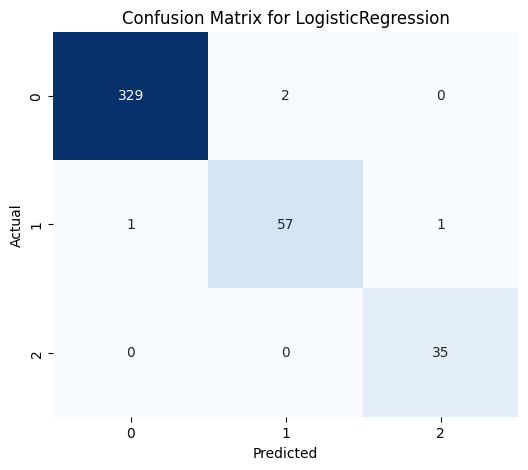

In [209]:
lr_kfold = LogisticRegression(random_state=42, max_iter=1000)
lr_kfold_report = perform_kfold_evaluation(lr_kfold, X, y, label='K-Fold')

### Random Forest

              precision    recall  f1-score    support
1.0            0.989239  0.997583  0.993388  331.00000
2.0            0.982304  0.935593  0.958160   59.00000
3.0            0.994444  0.994286  0.994285   35.20000
accuracy       0.988710  0.988710  0.988710    0.98871
macro avg      0.988663  0.975821  0.981944  425.20000
weighted avg   0.988710  0.988710  0.988576  425.20000


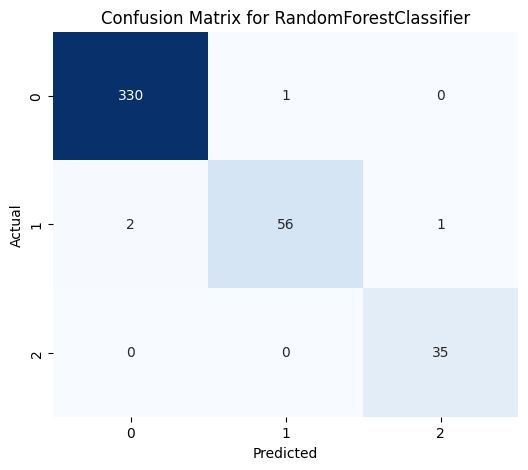

In [210]:
rf_kfold = RandomForestClassifier(random_state=42)
rf_kfold_report = perform_kfold_evaluation(rf_kfold, X, y, label='K-Fold')

### Gradient Boosted Classifier

              precision    recall  f1-score     support
1.0            0.988040  0.996979  0.992485  331.000000
2.0            0.978852  0.928814  0.952971   59.000000
3.0            0.994444  0.994286  0.994285   35.200000
accuracy       0.987299  0.987299  0.987299    0.987299
macro avg      0.987112  0.973359  0.979913  425.200000
weighted avg   0.987296  0.987299  0.987152  425.200000


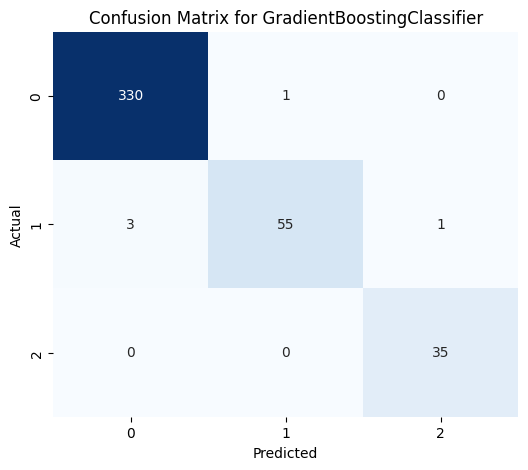

In [211]:
gb_kfold = GradientBoostingClassifier(random_state=42)
gb_kfold_report = perform_kfold_evaluation(gb_kfold, X, y, label='K-Fold')

### SVC

              precision    recall  f1-score     support
1.0            0.953386  0.998187  0.975238  331.000000
2.0            0.964694  0.813559  0.882130   59.000000
3.0            0.972488  0.796349  0.872340   35.200000
accuracy       0.955793  0.955793  0.955793    0.955793
macro avg      0.963523  0.869365  0.909903  425.200000
weighted avg   0.956538  0.955793  0.953759  425.200000


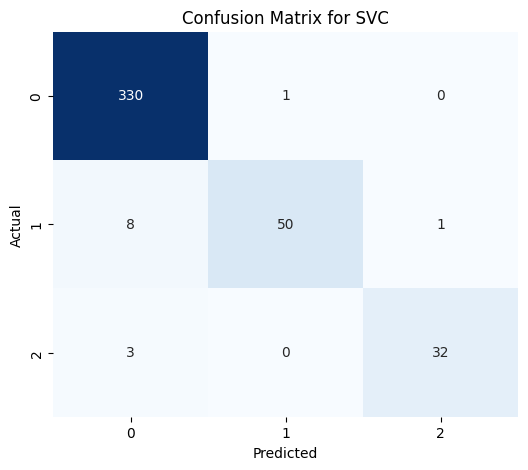

In [212]:
svc_kfold = SVC(random_state=42)
svc_kfold_report = perform_kfold_evaluation(svc_kfold, X, y, label='K-Fold')

### KNN

              precision    recall  f1-score     support
1.0            0.974595  0.995770  0.985060  331.000000
2.0            0.967621  0.898305  0.931256   59.000000
3.0            0.981629  0.897937  0.937665   35.200000
accuracy       0.974128  0.974128  0.974128    0.974128
macro avg      0.974615  0.930671  0.951327  425.200000
weighted avg   0.974216  0.974128  0.973663  425.200000


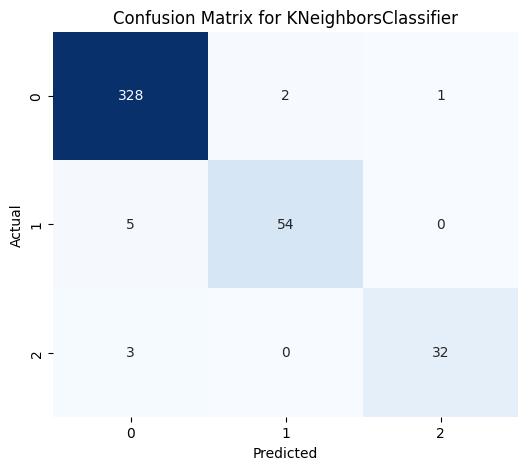

In [213]:
knn_kfold = KNeighborsClassifier()
knn_kfold_report = perform_kfold_evaluation(knn_kfold, X, y, label='K-Fold')

### K-Fold Results Summary

In [214]:
combined_kfold_report = pd.concat(
    objs=[lr_kfold_report, rf_kfold_report, gb_kfold_report, svc_kfold_report, knn_kfold_report], 
    keys=['Logistic Regression', 'Random Forest', 'Gradient Boosted Classifier', 'SVC', 'KNN']
)

combined_kfold_report

precision    recall  f1-score  \
Logistic Regression         1.0            0.990458  0.997583  0.993992   
                            2.0            0.982595  0.942373  0.961559   
                            3.0            0.994444  0.994286  0.994285   
                            accuracy       0.989649  0.989649  0.989649   
                            macro avg      0.989166  0.978081  0.983278   
                            weighted avg   0.989697  0.989649  0.989516   
Random Forest               1.0            0.989239  0.997583  0.993388   
                            2.0            0.982304  0.935593  0.958160   
                            3.0            0.994444  0.994286  0.994285   
                            accuracy       0.988710  0.988710  0.988710   
                            macro avg      0.988663  0.975821  0.981944   
                            weighted avg   0.988710  0.988710  0.988576   
Gradient Boosted Classifier 1.0            0.988040  0.996979  0.992485   
                            2.0            0.978852  0.928814  0.952971   
                            3.0            0.994444  0.994286  0.994285   
                            accuracy       0.987299  0.987299  0.987299   
                            macro avg      0.987112  0.973359  0.979913   
                            weighted avg   0.987296  0.987299  0.987152   
SVC                         1.0            0.953386  0.998187  0.975238   
                            2.0            0.964694  0.813559  0.882130   
                            3.0            0.972488  0.796349  0.872340   
                            accuracy       0.955793  0.955793  0.955793   
                            macro avg      0.963523  0.869365  0.909903   
                            weighted avg   0.956538  0.955793  0.953759   
KNN                         1.0            0.974595  0.995770  0.985060   
                            2.0            0.967621  0.898305  0.931256   
                            3.0            0.981629  0.897937  0.937665   
                            accuracy       0.974128  0.974128  0.974128   
                            macro avg      0.974615  0.930671  0.951327   
                            weighted avg   0.974216  0.974128  0.973663   

                                             support  
Logistic Regression         1.0           331.000000  
                            2.0            59.000000  
                            3.0            35.200000  
                            accuracy        0.989649  
                            macro avg     425.200000  
                            weighted avg  425.200000  
Random Forest               1.0           331.000000  
                            2.0            59.000000  
                            3.0            35.200000  
                            accuracy        0.988710  
                            macro avg     425.200000  
                            weighted avg  425.200000  
Gradient Boosted Classifier 1.0           331.000000  
                            2.0            59.000000  
                            3.0            35.200000  
                            accuracy        0.987299  
                            macro avg     425.200000  
                            weighted avg  425.200000  
SVC                         1.0           331.000000  
                            2.0            59.000000  
                            3.0            35.200000  
                            accuracy        0.955793  
                            macro avg     425.200000  
                            weighted avg  425.200000  
KNN                         1.0           331.000000  
                            2.0            59.000000  
                            3.0            35.200000  
                            accuracy        0.974128  
                            macro avg     425.200000  
                            weighted avg  425.200000

After K-fold validation, still, Logistic Regression is the best performing model with
- Accuracy = 0.9896, 
- f1 score = 0.9940, 0.9616, 0.9943 for the three target classes respectively. 
- Random Forest, and Gradient Boosted Classifier achieve similar f1 scores but their accuracy is lower.

# Hyperparameter Fine Tuning

Logistic Regression, and Random Forest are selected for hyperparameter fine tuning.

In [220]:
lr_hyperparams = {
    "C" : [0.01, 0.1, 1, 10, 100],
}

rf_hyperparams = {
    "n_estimators" : [100, 200, 300],
    "criterion" : ['gini', 'entropy', 'log_loss'],
    "max_depth" : [None, 10, 20, 30],
}

In [221]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr_grid_search = GridSearchCV(estimator=lr, param_grid=lr_hyperparams, cv=5, n_jobs=-1, verbose=2)
lr_grid_search.fit(X, y)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter i

In [222]:
rf = RandomForestClassifier(random_state=42)
rf_grid_search = GridSearchCV(estimator=rf, param_grid=rf_hyperparams, cv=5, n_jobs=-1, verbose=2)
rf_grid_search.fit(X, y)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 10, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

## Results of Best Models

In [223]:
lr_grid_search.best_params_, lr_grid_search.best_score_

({'C': 0.1}, np.float64(0.9811864125932063))

In [224]:
rf_grid_search.best_params_, rf_grid_search.best_score_

({'criterion': 'entropy', 'max_depth': None, 'n_estimators': 100},
 np.float64(0.984009942004971))

It is interesting to note that the performance of both the models has slightly decreased when grid search is performed. Therefore, the most optimum parameters are the default one.

# Inference of Test Data

In [236]:
datapoint = X_test.sample(1)
label = y_test.loc[datapoint.index]
predicted_label_lr = lr_base.predict(datapoint)
predicted_label_rf = rf_base.predict(datapoint)
print('Selected Sample: \n')
print(datapoint)

print(f'\nPredicted label by Logistic Regression: {predicted_label_lr[0]}')
print(f'\nPredicted label by Random Forest: {predicted_label_rf[0]}')

print(f'\nActual label: {label.values[0]}')

Selected Sample: 

       AC   FM    UC   DL   DS   DP        LB      ASTV  MSTV      ALTV  \
397 -0.25  0.0 -0.75  0.0  0.0  0.0  1.071429  0.551724  -0.8  1.818182   

         MLTV     Width  Nmax  Nzeros      Mode  Mean    Median  Variance  \
397 -0.112903 -0.738095  -0.5     0.0  0.947368  0.95  0.947368 -0.272727   

     Tendency_0.0  Tendency_1.0  A_1.0  B_1.0  C_1.0  D_1.0  E_1.0  AD_1.0  \
397             0             1      0      0      0      0      0       0   

     DE_1.0  LD_1.0  FS_1.0  SUSP_1.0  CLASS_2.0  CLASS_3.0  CLASS_4.0  \
397       0       0       0         1          0          0          0   

     CLASS_5.0  CLASS_6.0  CLASS_7.0  CLASS_8.0  CLASS_9.0  CLASS_10.0  
397          0          0          0          0          0           1  

Predicted label by Logistic Regression: 2.0

Predicted label by Random Forest: 2.0

Actual label: 2.0


# Model Serialization

In [238]:
# Save the final logistic regression model as pkl file
with open('./models/final_logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(lr_base, f)